<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/Computer_Vision_with_PyTorch_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

In [ ]:
1. В автомобілях типу Тесла
2. Військовими(дрони з самонаведенням)
3. Медична сфера(визначити тип пухлини за зображенням)

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

In [ ]:
Побачив візуально як проходить обробка зображення розбивається: на Red, Green, Blue канали, далі згортка  з визначеними параметрами,
застосовується нелінійність за допомогою ReLu, потім пулінг якщо потрібно, повторюється N разів,
далі результат конвертується в одновимірний вектор, далі вихід, наш аутпут

In [1]:
pip install --upgrade numpy scipy

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [3]:
# Налаштування навчальних даних
train_data = datasets.MNIST(
    root="data", # куди завантажити дані?
    train=True, # отримати навчальні дані
    download=True, # завантажити дані, якщо їх немає на диску
    transform=ToTensor(), # зображення приходять у форматі PIL, ми хочемо перетворити їх на тензори Torch
    target_transform=None # ви також можете перетворити мітки
)

# Налаштування тестових даних
test_data = datasets.MNIST(
    root="data",
    train=False, # отримати тестові дані
    download=True,
    transform=ToTensor()
)

## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

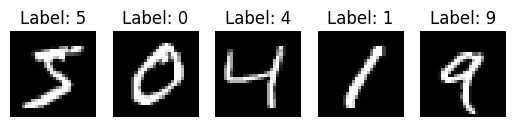

In [4]:
for i in range(5):
    image, label = train_data[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.show()

In [5]:
image.shape

torch.Size([1, 28, 28])

In [6]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [7]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [8]:
from torch.utils.data import DataLoader

In [9]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Довжина навчального dataloader: {len(train_dataloader)} партій по {BATCH_SIZE}")
print(f"Довжина тестового dataloader: {len(test_dataloader)} партій по {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7db77298ac00>, <torch.utils.data.dataloader.DataLoader object at 0x7db772a67200>)
Довжина навчального dataloader: 1875 партій по 32
Довжина тестового dataloader: 313 партій по 32


In [10]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [11]:
# Створити шар сплющення
flatten_model = nn.Flatten() # всі модулі nn функціонують як модель (можна виконати прямий прохід)

# Отримати один зразок
x = train_features_batch[0]

# Сплющити зразок
output = flatten_model(x) # виконати прямий прохід

# Вивести на екран, що сталося
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [12]:
# Налаштування коду, незалежного від пристрою
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [13]:
class MNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = MNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [14]:
import helper_functions

In [15]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()  # Функція втрат
optimizer = torch.optim.SGD(params=model_2.parameters(),  # Оптимізатор
                            lr=0.1)  # Швидкість навчання

In [16]:
import torch
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Час навчання на {device}: {total_time:.3f} секунд")
    return total_time

In [17]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Відправка даних на GPU
        X, y = X.to(device), y.to(device)

        # 1. Прямий прохід
        y_pred = model(X)

        # 2. Обчислення втрат
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Перехід від логітів до предсказаних міток

        # 3. Обнулення градієнтів оптимізатора
        optimizer.zero_grad()

        # 4. Зворотний прохід втрат
        loss.backward()

        # 5. Крок оптимізатора
        optimizer.step()

    # Обчислення втрат і точності за епоху та виведення результатів
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # перевести модель в режим оцінки
    # Увімкнути контекстний менеджер для інференції
    with torch.inference_mode():
        for X, y in data_loader:
            # Відправка даних на GPU
            X, y = X.to(device), y.to(device)

            # 1. Прямий прохід
            test_pred = model(X)

            # 2. Обчислення втрат і точності
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Перехід від логітів до предсказаних міток
            )

        # Коригування метрик і виведення результатів
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [18]:
torch.manual_seed(42)
from tqdm.auto import tqdm
# Вимірювання часу
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Навчання та тестування моделі
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33279 | Train accuracy: 88.81%
Test loss: 0.07328 | Test accuracy: 97.72%

Епоха: 1
---------
Train loss: 0.08206 | Train accuracy: 97.44%
Test loss: 0.06173 | Test accuracy: 98.02%

Епоха: 2
---------
Train loss: 0.06401 | Train accuracy: 98.01%
Test loss: 0.05282 | Test accuracy: 98.23%

Епоха: 3
---------
Train loss: 0.05579 | Train accuracy: 98.25%
Test loss: 0.05866 | Test accuracy: 98.02%

Епоха: 4
---------
Train loss: 0.04983 | Train accuracy: 98.47%
Test loss: 0.04363 | Test accuracy: 98.43%

Час навчання на cuda: 58.789 секунд


In [19]:
# CPU training
torch.manual_seed(42)
model_2_cpu = MNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to("cpu")
optimizer_cpu = torch.optim.SGD(params=model_2_cpu.parameters(),
                            lr=0.1)
# Training loop on CPU
print("\n--- Training on CPU ---")
train_time_start_model_2_cpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2_cpu,
        loss_fn=loss_fn,
        optimizer=optimizer_cpu,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )
    test_step(data_loader=test_dataloader,
        model=model_2_cpu,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )

train_time_end_model_2_cpu = timer()
total_train_time_model_2_cpu = print_train_time(start=train_time_start_model_2_cpu,
                                           end=train_time_end_model_2_cpu,
                                           device="cpu")


--- Training on CPU ---


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.27735 | Train accuracy: 91.00%
Test loss: 0.07892 | Test accuracy: 97.34%

Епоха: 1
---------
Train loss: 0.07122 | Train accuracy: 97.76%
Test loss: 0.04805 | Test accuracy: 98.49%

Епоха: 2
---------
Train loss: 0.05649 | Train accuracy: 98.24%
Test loss: 0.04469 | Test accuracy: 98.50%

Епоха: 3
---------
Train loss: 0.04700 | Train accuracy: 98.48%
Test loss: 0.04458 | Test accuracy: 98.54%

Епоха: 4
---------
Train loss: 0.04171 | Train accuracy: 98.66%
Test loss: 0.03978 | Test accuracy: 98.79%

Час навчання на cpu: 177.145 секунд


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

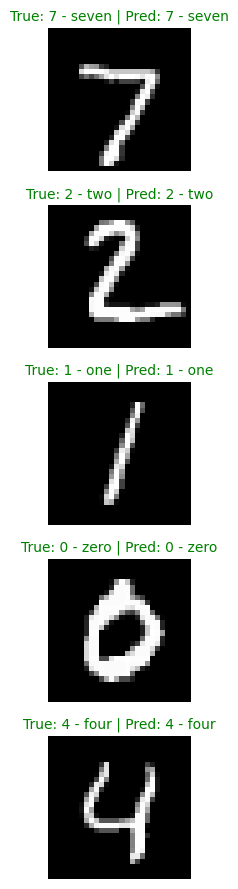

In [20]:
model_2.eval()
with torch.inference_mode():
    # Отримати один пакет тестових даних
    test_features_batch, test_labels_batch = next(iter(test_dataloader))
    test_features_batch, test_labels_batch = test_features_batch.to(device), test_labels_batch.to(device)

    # Зробити прогнози
    test_preds_logits = model_2(test_features_batch)
    test_preds = test_preds_logits.argmax(dim=1)

# Перемістити дані на CPU для візуалізації
test_features_batch_cpu = test_features_batch.cpu()
test_labels_batch_cpu = test_labels_batch.cpu()
test_preds_cpu = test_preds.cpu()

# Візуалізувати щонайменше 5 зразків
plt.figure(figsize=(9, 9))
rows = 5
cols = 1
for i in range(min(len(test_features_batch_cpu), 5)):
    plt.subplot(rows, cols, i+1)
    plt.imshow(test_features_batch_cpu[i].squeeze(), cmap='gray')
    # Створення назви підграфіка
    title_text = f"True: {class_names[test_labels_batch_cpu[i]]} | Pred: {class_names[test_preds_cpu[i]]}"
    if test_labels_batch_cpu[i] == test_preds_cpu[i]:
        plt.title(title_text, fontsize=10, color="green")
    else:
        plt.title(title_text, fontsize=10, color="red")
    plt.axis(False)
plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [21]:
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19

0.23.4


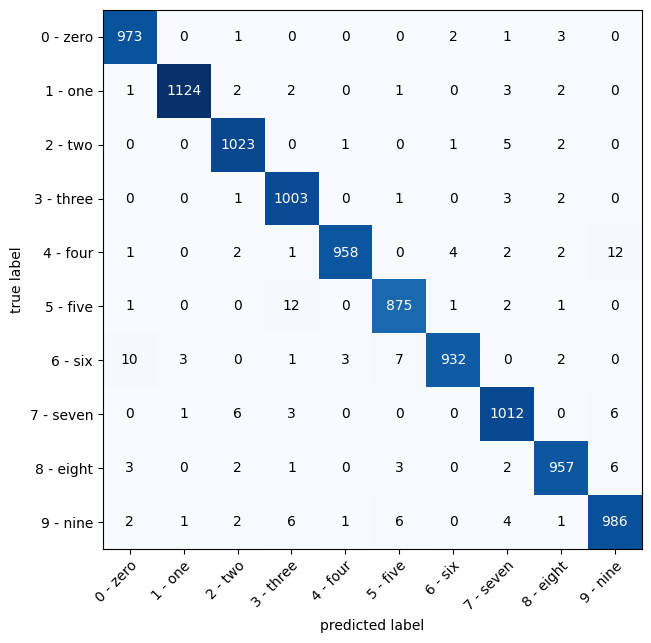

In [24]:

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Make predictions on the entire test dataset
model_2.eval()
y_preds = []
y_true = []
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_logits = model_2(X)
        y_pred = y_logits.argmax(dim=1)
        y_preds.append(y_pred.cpu())
        y_true.append(y.cpu())

y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)

# 2. Налаштування екземпляра матриці плутанини та порівняння прогнозів з цілями
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=y_true_tensor)

# 3. Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib любить працювати з NumPy
    class_names=class_names, # перетворення міток рядків і стовпців на назви класів
    figsize=(10, 7)
)
plt.show()

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [25]:
import numpy as np

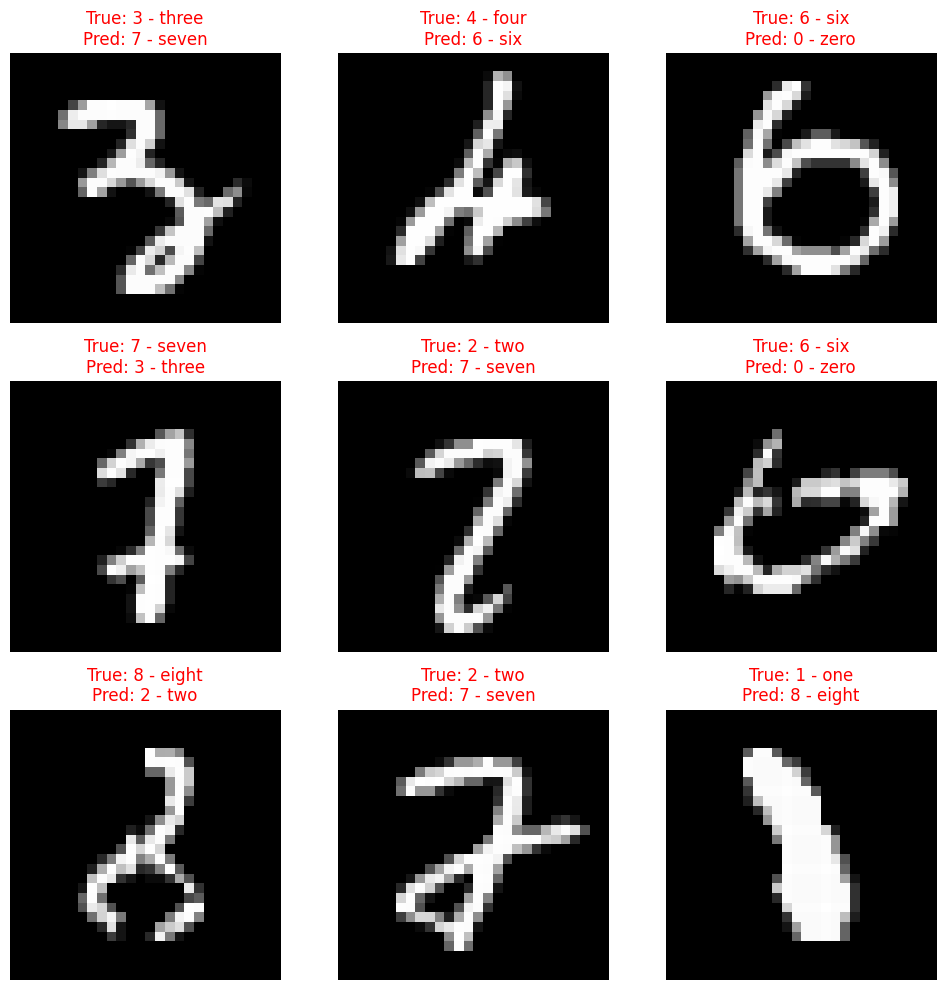

In [27]:
misclassified_indices = np.where(y_pred_tensor != y_true_tensor)[0]
num_to_display = min(9, len(misclassified_indices))
display_indices = misclassified_indices[:num_to_display]

plt.figure(figsize=(10, 10))
for i, idx in enumerate(display_indices):
    image, true_label = test_data[idx]
    predicted_label = y_pred_tensor[idx]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [29]:
random_tensor = torch.rand(1, 3, 64, 64)
print(f"Random tensor shape: {random_tensor.shape}")

conv_layer_small_kernel = nn.Conv2d(in_channels=3,
                                  out_channels=10,
                                  kernel_size=3,
                                  stride=1,
                                  padding=0)

output_small_kernel = conv_layer_small_kernel(random_tensor)
print(f"Output shape with kernel_size = 3: {output_small_kernel.shape}")
conv_layer_large_kernel = nn.Conv2d(in_channels=3,
                                  out_channels=10,
                                  kernel_size=9,
                                  stride=1,
                                  padding=0)

output_large_kernel = conv_layer_large_kernel(random_tensor)
print(f"Output shape with kernel_size = 9: {output_large_kernel.shape}")
conv_layer_padded = nn.Conv2d(in_channels=3,
                              out_channels=10,
                              kernel_size=3,
                              stride=1,
                              padding=1)
output_padded = conv_layer_padded(random_tensor)
print(f"Output shape with kernel_size = 3 and padding=1: {output_padded.shape}")

Random tensor shape: torch.Size([1, 3, 64, 64])
Output shape with kernel_size = 3: torch.Size([1, 10, 62, 62])
Output shape with kernel_size = 9: torch.Size([1, 10, 56, 56])
Output shape with kernel_size = 3 and padding=1: torch.Size([1, 10, 64, 64])


З значень кернел сайзу бачимо що чим більше значення, тим менше розмірність тензора, так як охоплюється більша область вихідного тензора за один крок, відповідно потрібно менше кроків для проходження по всьому ряду